## **DAY 9 — Advanced Feature Engineering + Feature Selection**

<br>
<br>

### **1. Why use Advanced Feature Engineering?**
Raw data often contains hidden relationships that simple models can't see. By transforming data, we:
*   **Capture Non-linearity**: Models like Linear Regression assume straight lines; transformations allow them to learn curves.
*   **Normalize Scale**: Log transforms compress outliers and make data more Gaussian (Normal).
*   **Add Domain Knowledge**: Ratios (like Income-to-Debt) often predict behavior better than raw numbers alone.

---

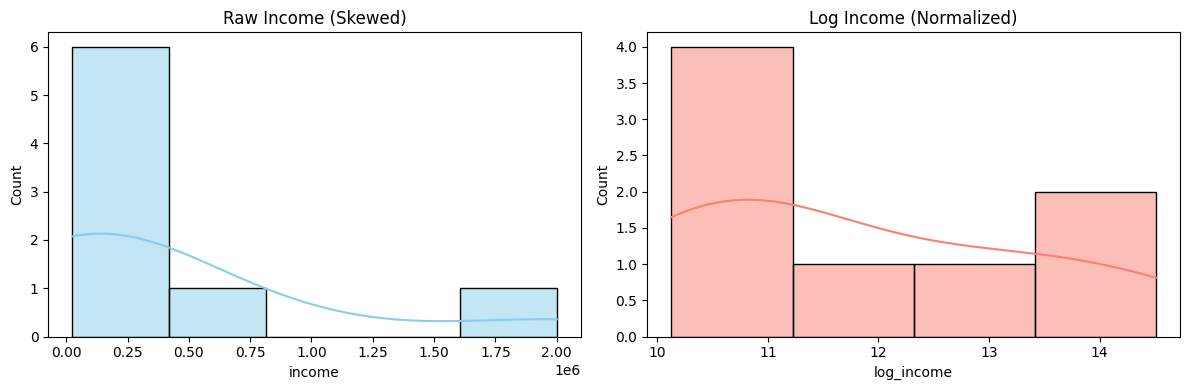

,income,rooms,occupants,year_built,location_score,has_garden,distance_to_center,house_type,last_renovated,log_income,rooms_per_occupant,age_at_sale,is_modern,location_category
0,25000,3,1,1950,2,0,15.5,Apartment,1980.0,10.126671,3.00,74,0,Rural
1,30000,4,2,1970,3,0,12.1,Apartment,0.0,10.308986,2.00,54,0,Rural
2,45000,2,4,1990,5,1,8.4,House,2005.0,10.714440,0.50,34,0,Suburban
3,50000,5,3,2010,4,0,10.2,Apartment,0.0,10.819798,1.67,14,1,Rural
4,120000,8,5,2015,8,1,3.1,House,2018.0,11.695255,1.60,9,1,Suburban
5,350000,12,6,2020,9,1,1.5,Penthouse,2021.0,12.765691,2.00,4,1,Downtown
6,800000,15,2,2022,9,1,0.8,Villa,0.0,13.592368,7.50,2,1,Downtown
7,2000000,20,1,2023,10,1,0.5,Villa,2023.0,14.508658,20.00,1,1,Downtown


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a DataFrame
data = {
    'income': [25000, 30000, 45000, 50000, 120000, 350000, 800000, 2000000],
    'rooms': [3, 4, 2, 5, 8, 12, 15, 20],
    'occupants': [1, 2, 4, 3, 5, 6, 2, 1],
    'year_built': [1950, 1970, 1990, 2010, 2015, 2020, 2022, 2023],
    'location_score': [2, 3, 5, 4, 8, 9, 9, 10],
    'has_garden': [0, 0, 1, 0, 1, 1, 1, 1],
    'distance_to_center': [15.5, 12.1, 8.4, 10.2, 3.1, 1.5, 0.8, 0.5],
    'house_type': ['Apartment', 'Apartment', 'House', 'Apartment', 'House', 'Penthouse', 'Villa', 'Villa'],
    'last_renovated': [1980, None, 2005, None, 2018, 2021, None, 2023]
}
df = pd.DataFrame(data)

# FIX MISSING VALUES: Using fillna(0) to handle actual NaN types
df['last_renovated'] = df['last_renovated'].fillna(0)

# --- FEATURE ENGINEERING ---
df['log_income'] = np.log1p(df['income'])
df['rooms_per_occupant'] = (df['rooms'] / df['occupants']).round(2)
df['age_at_sale'] = 2024 - df['year_built']
df['is_modern'] = (df['year_built'] > 2000).astype(int)

# Binning distance
df['location_category'] = pd.cut(df['distance_to_center'],
                                 bins=[0, 2, 10, 20],
                                 labels=['Downtown', 'Suburban', 'Rural'])

# Visualization of original vs log income
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['income'], kde=True, ax=ax1, color='skyblue').set_title('Raw Income (Skewed)')
sns.histplot(df['log_income'], kde=True, ax=ax2, color='salmon').set_title('Log Income (Normalized)')
plt.tight_layout()
plt.show()

display(df)

## **PART 2 — Polynomial Features**

Linear models assume a straight line relationship ($y = mx + b$). However, many real-world trends are curved. Polynomial features help a model learn these curves by adding powers of the original features (e.g., $x^2$, $x^3$).

### **Why use them?**
*   **Capture Acceleration**: Used when the target grows faster (or slower) as the feature increases.
*   **Interaction Effects**: (In higher degrees) they capture how two features multiply together.

### **PolynomialFeatures Parameters (Summary)**

*   **`degree`**: Power of features (e.g., `degree=2` creates $x^2$).
*   **`interaction_only`**: If `True`, creates $x_1 \times x_2$ but skip squares ($x^2$).
*   **`include_bias`**: Adds a column of 1s. Usually set to `False` for regression models.

Original Feature vs Polynomial Features:


,Experience,Experience_Squared
0,1.0,1.0
1,2.0,4.0
2,3.0,9.0
3,4.0,16.0
4,5.0,25.0


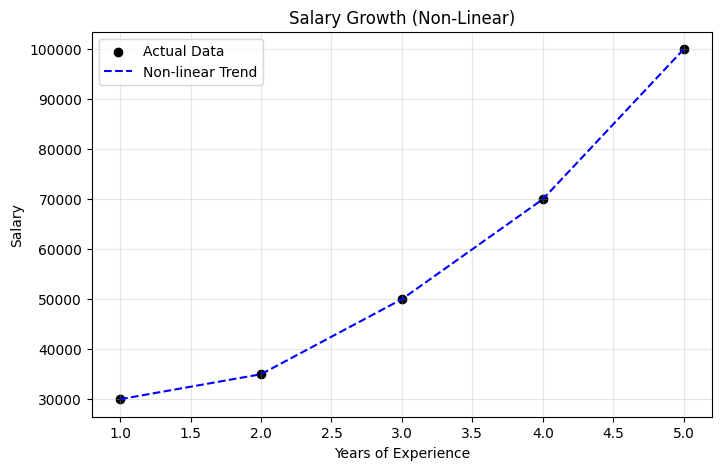

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Create a simple Experience vs Salary dataset
data_poly = {
    'Experience': [1, 2, 3, 4, 5],
    'Salary': [30000, 35000, 50000, 70000, 100000]
}
df_poly = pd.DataFrame(data_poly)

# 2. Initialize PolynomialFeatures (Degree 2 creates x^2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# 3. Fit and transform the 'Experience' column
# We reshape or use [[]] because the transformer expects a 2D array
poly_features = poly.fit_transform(df_poly[['Experience']])

# 4. Create a new DataFrame to visualize the result
poly_df = pd.DataFrame(
    poly_features,
    columns=['Experience', 'Experience_Squared']
)

print("Original Feature vs Polynomial Features:")
display(poly_df)

# Visualize the 'curve' vs 'line'
plt.figure(figsize=(8, 5))
plt.scatter(df_poly['Experience'], df_poly['Salary'], color='black', label='Actual Data')
plt.plot(df_poly['Experience'], df_poly['Salary'], color='blue', linestyle='--', label='Non-linear Trend')
plt.title('Salary Growth (Non-Linear)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **PART 3 — Interaction Features**

Interaction features represent the combined effect of two or more features. Instead of looking at variables in isolation, we look at how they amplify or suppress each other.

### **Why are they important?**
*   **Synergy**: A house in a great location might be worth much more if it is also modern.
*   **Context**: High income might lead to different spending habits depending on the family size (Interaction: `income * occupants`).
*   **Capturing Complexity**: Linear models treat each feature independently; interactions let them understand context.

New Interaction Feature: location_x_modernity


,location_score,year_built,is_modern,location_x_modernity
3,4,2010,1,4
4,8,2015,1,8
5,9,2020,1,9
6,9,2022,1,9
7,10,2023,1,10


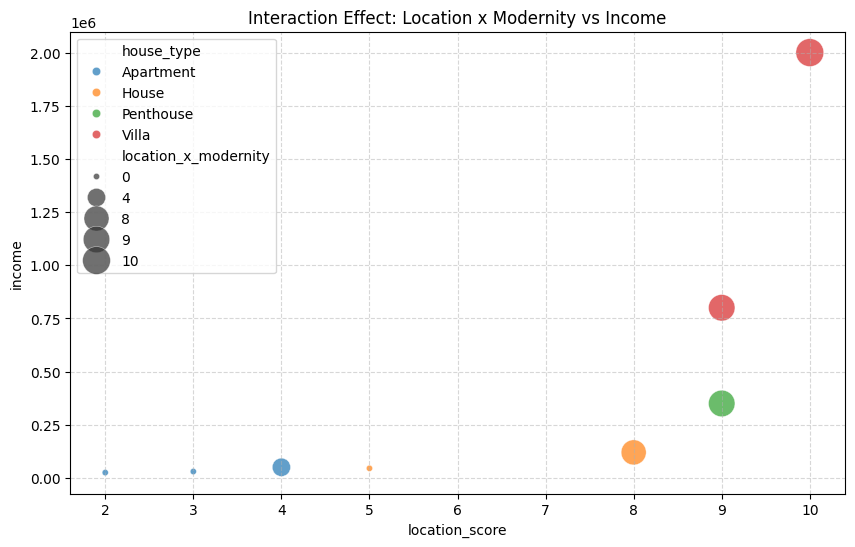

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Let's create an interaction between Location Score and House Age
# Theory: A high location score is even more valuable for newer houses.

df['location_x_modernity'] = df['location_score'] * df['is_modern']

# Display the original features and the new interaction feature
print("New Interaction Feature: location_x_modernity")
display(df[['location_score', 'year_built', 'is_modern', 'location_x_modernity']].tail())

# Visualization: How interaction separates the data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='location_score', y='income',
                size='location_x_modernity', hue='house_type',
                sizes=(20, 400), alpha=0.7)
plt.title('Interaction Effect: Location x Modernity vs Income')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### **Common Interaction Types**
1.  **Product**: `Feature_A * Feature_B` (Amplification)
2.  **Ratio**: `Feature_A / Feature_B` (e.g., Rooms per Occupant)
3.  **Boolean logic**: `is_weekend * hours_open` (Conditional behavior)

## **PART 4 — Binning**

Binning converts continuous numerical values into discrete groups (categories).

### **Why is it useful?**
*   **Reduce Noise**: Minor fluctuations in data matter less when grouped.
*   **Simplify Patterns**: It's often easier for a model to learn from "High Income" vs. "Low Income" than specific dollar amounts.
*   **Improve Interpretability**: Categorical groups are easier for humans to understand and act upon.

Data after Binning:


,income,income_bracket,age_at_sale,building_generation
0,25000,Budget,74,Vintage
1,30000,Budget,54,Vintage
2,45000,Budget,34,Vintage
3,50000,Budget,14,Modern
4,120000,Mid-Range,9,New Construction


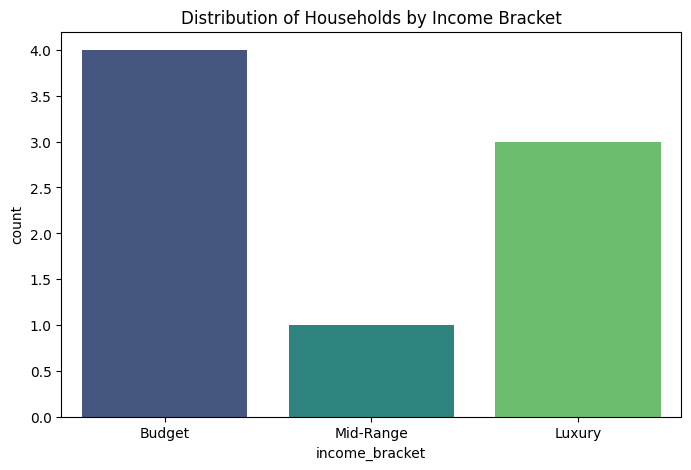

In [ ]:
# 1. Create Bins for Income
df['income_bracket'] = pd.cut(
    df['income'],
    bins=[0, 50000, 200000, float('inf')],
    labels=['Budget', 'Mid-Range', 'Luxury']
)

# 2. Create Bins for House Age (Generations)
df['building_generation'] = pd.cut(
    df['age_at_sale'],
    bins=[0, 10, 30, 100],
    labels=['New Construction', 'Modern', 'Vintage']
)

print("Data after Binning:")
display(df[['income', 'income_bracket', 'age_at_sale', 'building_generation']].head())

# Visualization: Distribution of Income Brackets
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='income_bracket', palette='viridis', hue='income_bracket', legend=False)
plt.title('Distribution of Households by Income Bracket')
plt.show()

## **PART 5 — Log Transformation**

Log transformation is a powerful mathematical tool used to handle **skewed data**.

### **The Problem: Outliers**
In datasets like income or house prices, a few extremely large values (outliers) can pull the mean away from the median, making the data "right-skewed." Most machine learning models perform better when data follows a Gaussian (Normal) distribution.

### **The Solution: $y = \log(x + 1)$**
We use `np.log1p` (which is $\log(1+x)$) because:
1. It compresses the scale of large values.
2. It prevents errors if a value is zero (since $\log(0)$ is undefined).

### **Benefits**
*   ✅ **Reduces Skewness**: Pulls outliers closer to the rest of the data.
*   ✅ **Stabilizes Variance**: Makes the spread of data more consistent.
*   ✅ **Improves ML Performance**: Helps linear models find better fit lines.

Original Income vs Log Transformed Income:


,income,log_income
0,25000,10.126671
1,30000,10.308986
2,45000,10.714440
3,50000,10.819798
4,120000,11.695255


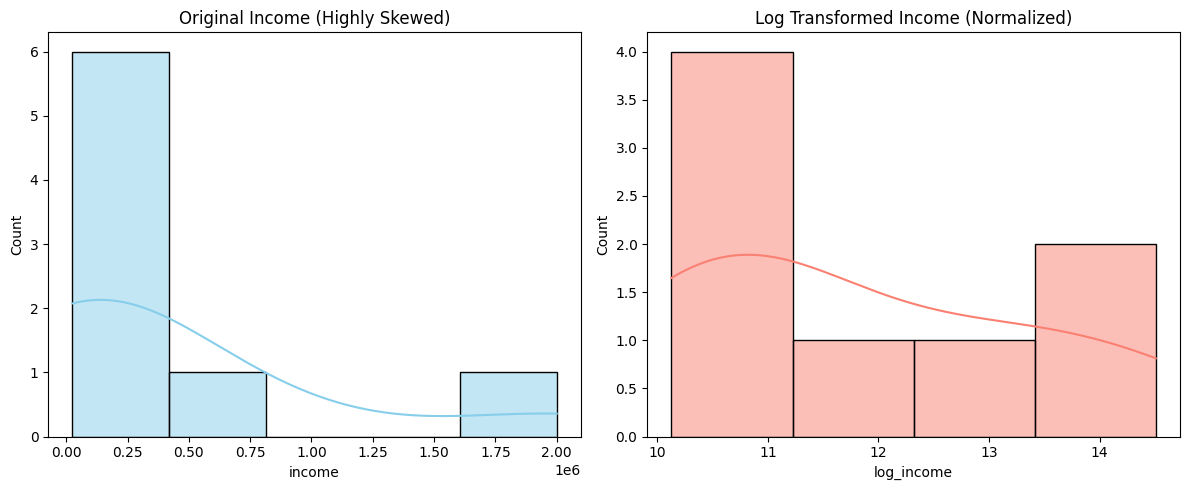

In [ ]:
import numpy as np

# Apply Log Transformation to Income
df['log_income'] = np.log1p(df['income'])

# Show the effect
print("Original Income vs Log Transformed Income:")
display(df[['income', 'log_income']].head())

# Visualization: Comparing Distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['income'], kde=True, color='skyblue')
plt.title('Original Income (Highly Skewed)')

plt.subplot(1, 2, 2)
sns.histplot(df['log_income'], kde=True, color='salmon')
plt.title('Log Transformed Income (Normalized)')

plt.tight_layout()
plt.show()

## **PART 6 — Feature Selection**

Feature selection is the process of choosing the most relevant columns for your model.

### **Why do it?**
*   **Reduce Noise**: Irrelevant features can confuse the model.
*   **Prevent Overfitting**: Models might find patterns in random noise if they have too many variables to look at.
*   **Speed**: Fewer features mean faster training and prediction times.

---

## **PART 7 — Correlation-Based Selection**

One of the simplest ways to select features is by checking their **Correlation**. If two features are highly correlated (e.g., 0.95 or higher), they provide the same information. Keeping both is redundant and can destabilize some models.

Correlation Matrix:


,income,rooms,occupants,year_built,location_score,has_garden,distance_to_center,last_renovated,log_income,rooms_per_occupant,age_at_sale,is_modern,location_x_modernity
income,1.00,0.91,-0.40,0.53,0.70,0.47,-0.65,0.17,0.88,0.98,-0.53,0.47,0.66
rooms,0.91,1.00,-0.13,0.74,0.88,0.59,-0.85,0.09,0.98,0.84,-0.74,0.72,0.89
occupants,-0.40,-0.13,1.00,0.40,0.30,0.45,-0.34,0.30,-0.04,-0.54,-0.40,0.30,0.24
year_built,0.53,0.74,0.40,1.00,0.89,0.71,-0.91,-0.01,0.80,0.39,-1.00,0.91,0.89
location_score,0.70,0.88,0.30,0.89,1.00,0.87,-0.99,0.25,0.93,0.57,-0.89,0.78,0.94
has_garden,0.47,0.59,0.45,0.71,0.87,1.00,-0.87,0.47,0.71,0.33,-0.71,0.47,0.67
distance_to_center,-0.65,-0.85,-0.34,-0.91,-0.99,-0.87,1.00,-0.18,-0.91,-0.51,0.91,-0.78,-0.93
last_renovated,0.17,0.09,0.30,-0.01,0.25,0.47,-0.18,1.00,0.13,0.14,0.01,-0.06,0.13
log_income,0.88,0.98,-0.04,0.80,0.93,0.71,-0.91,0.13,1.00,0.79,-0.80,0.73,0.90
rooms_per_occupant,0.98,0.84,-0.54,0.39,0.57,0.33,-0.51,0.14,0.79,1.00,-0.39,0.38,0.55


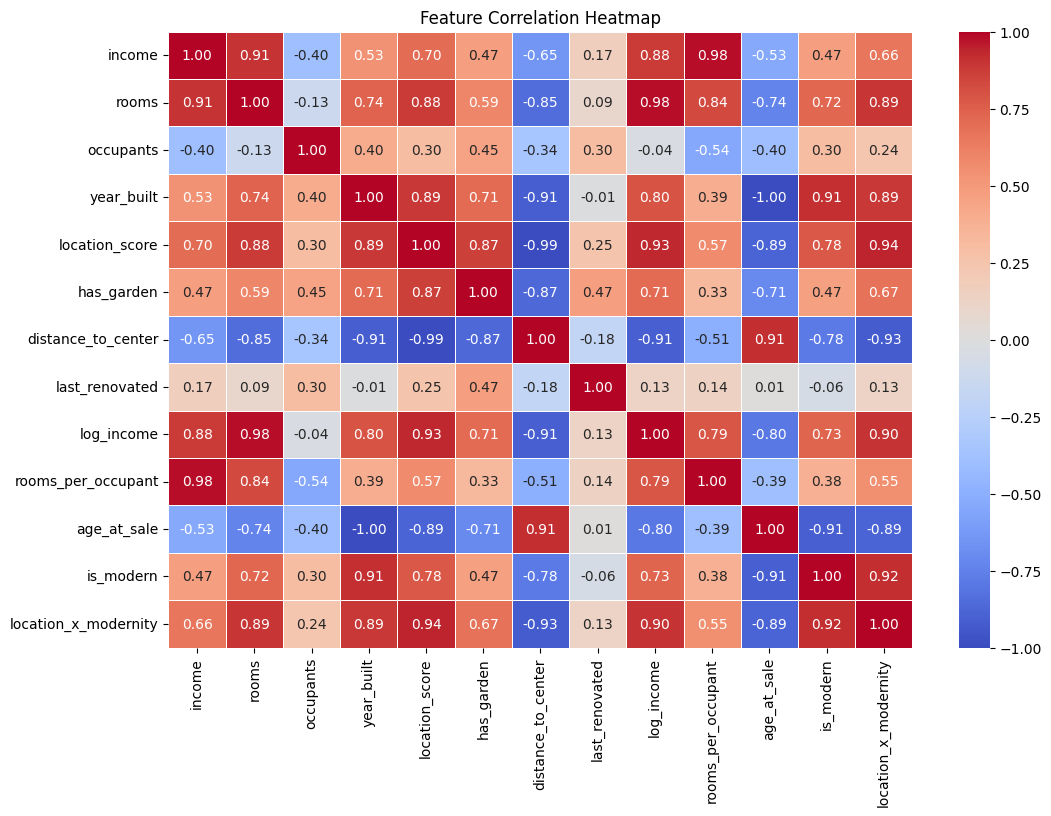

In [ ]:
# 1. Calculate the Correlation Matrix
# We filter for numeric columns since correlation requires numbers
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. Display the Matrix
print("Correlation Matrix:")
display(corr_matrix.round(2))

# 3. Create a Heatmap for Visual Interpretation
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### **How to Interpret the Heatmap**
*   **Close to 1.0**: Strong positive relationship (as A goes up, B goes up).
*   **Close to -1.0**: Strong negative relationship (as A goes up, B goes down).
*   **Close to 0.0**: No linear relationship.

**Action Plan**: If you see two variables with a correlation > 0.9, consider dropping one to simplify your model.

## **PART 8 — Feature Importance**

While correlation measures linear relationships, **Feature Importance** tells us how much each feature contributes to a model's predictive power (even for non-linear relationships).

### **Why is it important?**
*   **Ranking**: It ranks features from most to least useful.
*   **Simplification**: You can confidently remove features with near-zero importance.
*   **Insights**: It helps you understand what truly drives your target variable (e.g., Is 'Location' more important than 'Size'?).

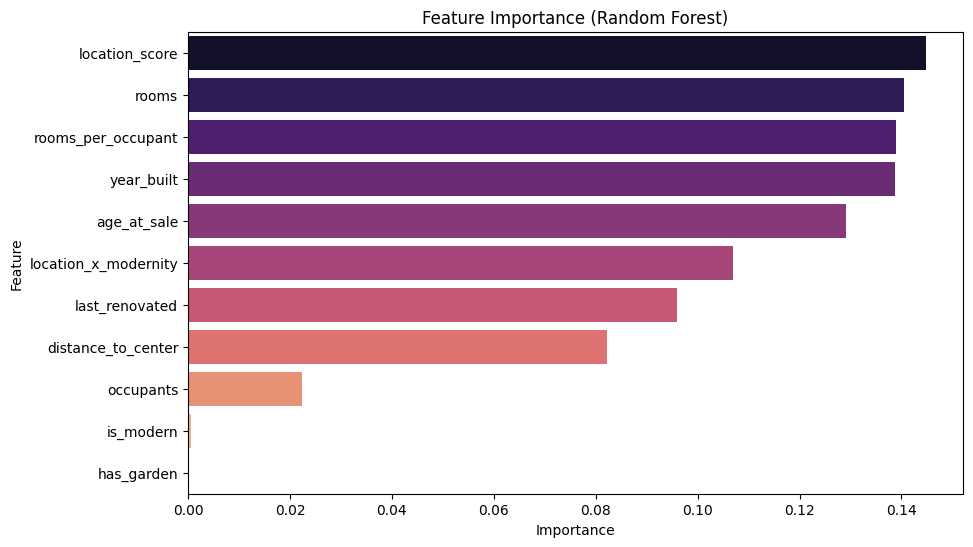

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare data (dropping non-numeric and target-leaking columns)
X = df.select_dtypes(include=[np.number]).drop(columns=['income', 'log_income'])
y = df['income']

# 2. Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. Get importance levels
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.show()

## **PART 9 — Dimensionality Reduction (PCA)**

PCA simplifies complex datasets by creating new, uncorrelated variables called **Principal Components**. This is particularly useful for visualizing high-dimensional data or speeding up model training.

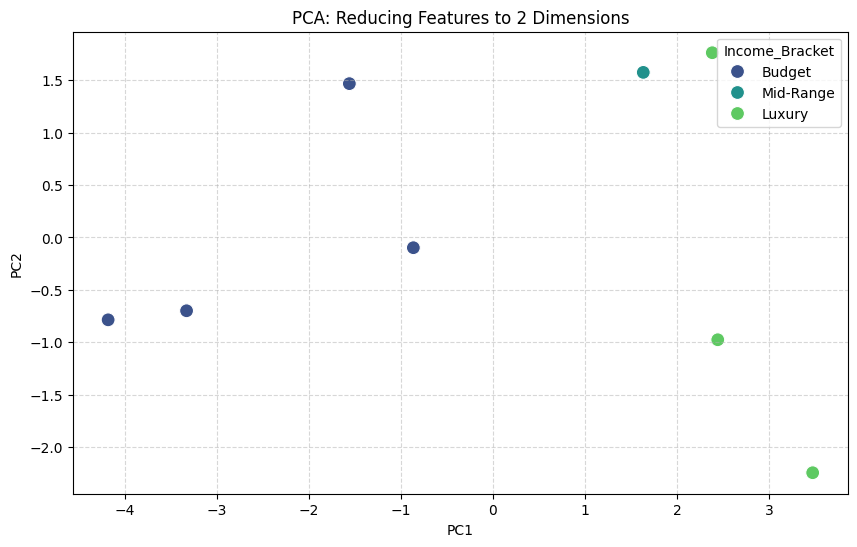

Total Variance Explained by 2 components: 82.86%


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Scale the data (PCA is sensitive to variance, so scaling is required)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Initialize PCA and reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Create a DataFrame for visualization
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Income_Bracket'] = df['income_bracket'].values

# 4. Plot the results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Income_Bracket', palette='viridis', s=100)
plt.title('PCA: Reducing Features to 2 Dimensions')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Explained Variance
print(f"Total Variance Explained by 2 components: {sum(pca.explained_variance_ratio_):.2%}")

## **PART 10 — Feature Scaling Revisited**

Many machine learning algorithms (like PCA, SVMs, and Neural Networks) are sensitive to the scale of your data. If one feature ranges from 0-1 and another from 0-1,000,000, the model might incorrectly assume the larger number is more 'important.'

### **StandardScaler**
StandardScaler shifts your data so the **mean is 0** and the **standard deviation is 1** using the Z-score formula:

$$z = \frac{x - \mu}{\sigma}$$

Where:
*   $x$ = original value
*   $\mu$ = mean
*   $\sigma$ = standard deviation

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Transform our numeric feature set X
X_scaled_example = scaler.fit_transform(X)

# Preview the scaled data
X_scaled_df = pd.DataFrame(X_scaled_example, columns=X.columns)
print("Features after StandardScaler (Mean ≈ 0, Std ≈ 1):")
display(X_scaled_df.head())

Features after StandardScaler (Mean ≈ 0, Std ≈ 1):


,rooms,occupants,year_built,location_score,has_garden,distance_to_center,last_renovated,rooms_per_occupant,age_at_sale,is_modern,location_x_modernity
0,-0.931256,-1.154701,-1.954035,-1.463127,-1.290994,1.659278,0.744312,-0.293358,1.954035,-1.290994,-1.186782
1,-0.765699,-0.577350,-1.172421,-1.118862,-1.290994,1.031568,-1.290886,-0.457820,1.172421,-1.290994,-1.186782
2,-1.096813,0.577350,-0.390807,-0.430331,0.774597,0.348472,0.770009,-0.704512,0.390807,-1.290994,-1.186782
3,-0.600143,0.000000,0.390807,-0.774597,-1.290994,0.680789,-1.290886,-0.512092,-0.390807,0.774597,-0.237356
4,-0.103473,1.154701,0.586210,0.602464,0.774597,-0.630018,0.783371,-0.523605,-0.586210,0.774597,0.712069


## **PART 11 — FULL ADVANCED FEATURE ENGINEERING EXAMPLE**

Let's pull all these concepts together—Interactions, Polynomials, Logs, and Scaling—into a single workflow.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Step 1 — Dataset
data_full = {
    "Experience": [1, 2, 3, 4, 5],
    "Income": [30000, 40000, 50000, 70000, 100000]
}
df_full = pd.DataFrame(data_full)

# Step 2 — Interaction Feature
df_full["interaction"] = df_full["Experience"] * df_full["Income"]

# Step 3 — Polynomial Features (Degree 2 for Experience)
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_out = poly.fit_transform(df_full[["Experience"]])
df_full["Exp_Squared"] = poly_out[:, 1]

# Step 4 — Log Transform (Handle Income Skew)
df_full["log_income"] = np.log1p(df_full["Income"])

# Step 5 — Feature Scaling
scaler = StandardScaler()
df_full[["Income_Scaled", "Interaction_Scaled"]] = scaler.fit_transform(df_full[["Income", "interaction"]])

print("The Result of Combined Feature Engineering:")
display(df_full)

The Result of Combined Feature Engineering:


,Experience,Income,interaction,Exp_Squared,log_income,Income_Scaled,Interaction_Scaled
0,1,30000,30000,1.0,10.308986,-1.128152,-1.056682
1,2,40000,80000,4.0,10.596660,-0.725241,-0.759861
2,3,50000,150000,9.0,10.819798,-0.322329,-0.344312
3,4,70000,280000,16.0,11.156265,0.483494,0.427422
4,5,100000,500000,25.0,11.512935,1.692228,1.733434


## **PART 12 — REAL INDUSTRY UNDERSTANDING**

### **Why Feature Engineering Matters More Than Models**
In industry, the quality of your data and the features you create usually impact performance more than the specific algorithm you choose:

*   **Simple model + amazing features** > **Complex model + poor features**

### **Finance Usage**
Quantitative finance relies heavily on these techniques for:
*   **Trading Systems**: Creating indicators from raw price data.
*   **Forecasting Models**: Predicting stock trends or market volatility.
*   **Fraud Detection**: Identifying unusual spending patterns through ratios and aggregations.

Used heavily in **hedge funds, investment banks, and quantitative finance labs** to find an "edge" in the market.

_________________________________________
<br>
<br>

## **PRATICE QUESTION**

In [ ]:
#import pandas as pd
import numpy as np

# Creating a complex 'Interview Level' E-commerce Dataset
np.random.seed(42)
n_rows = 15

data_interview = {
    'user_id': range(101, 101 + n_rows),
    'age': [25, 34, np.nan, 45, 23, 55, np.nan, 28, 40, 31, 22, 38, np.nan, 42, 50],
    'device_type': ['Mobile', 'Desktop', 'Mobile', 'Tablet', 'Desktop', 'Desktop', 'Mobile', 'Mobile', 'Tablet', 'Desktop', 'Mobile', 'Desktop', 'Mobile', 'Mobile', 'Desktop'],
    'sessions_per_month': [12, 45, 8, 20, 15, 60, 5, 22, 18, 30, 10, 25, 7, 33, 50],
    'avg_session_duration': [5.2, 15.5, 3.1, 8.4, 4.8, 25.0, 2.5, 10.1, 7.2, 12.4, 4.0, 9.5, 2.8, 14.2, 20.0],
    'discount_used': [1, 0, 1, 1, 0, 1, np.nan, 0, 1, 0, 1, 0, np.nan, 1, 1],
    'total_purchase_amount': [150.50, 1200.00, 45.00, 350.00, 210.00, 5000.00, 25.00, 400.00, 310.00, 850.00, 110.00, 600.00, 30.00, 980.00, 4200.00]
}

df_interview = pd.DataFrame(data_interview)

print("Interview Practice Dataset:")
display(df_interview.head())
print("\nMissing Values Summary:")
print(df_interview.isnull().sum())

# TASK:
# 1. Handle missing values in 'age' and 'discount_used'.
# 2. Create an interaction feature between 'sessions_per_month' and 'avg_session_duration'.
# 3. Apply a Log Transform to 'total_purchase_amount'.
# 4. Use StandardScaler on the numerical features.

Interview Practice Dataset:


,user_id,age,device_type,sessions_per_month,avg_session_duration,discount_used,total_purchase_amount
0,101,25.0,Mobile,12,5.2,1.0,150.5
1,102,34.0,Desktop,45,15.5,0.0,1200.0
2,103,NaN,Mobile,8,3.1,1.0,45.0
3,104,45.0,Tablet,20,8.4,1.0,350.0
4,105,23.0,Desktop,15,4.8,0.0,210.0



Missing Values Summary:
user_id                  0
age                      3
device_type              0
sessions_per_month       0
avg_session_duration     0
discount_used            2
total_purchase_amount    0
dtype: int64


In [ ]:
#STEP 1: HANDLE MISSING VALUES
df_interview['age'] = df_interview['age'].fillna(0)
df_interview['discount_used'] = df_interview['discount_used'].fillna(0)

In [ ]:
#STEP 2: INTERACTION FEATURES
df_interview['total_monthly_time'] = df_interview['sessions_per_month'] * df_interview['avg_session_duration']

#STEP 3: APPLY LOG1P
df_interview['log_purchase_amount'] = np.log1p(df_interview['total_purchase_amount'])

#STEP 4: IMPLEMENT STANDARD SCALER
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

scaler = StandardScaler()
# Now 'total_monthly_time' exists in df_interview, so this will work:
scaled_data = scaler.fit_transform(df_interview[['age', 'sessions_per_month', 'avg_session_duration', 'total_monthly_time', 'log_purchase_amount']])

polynomial = PolynomialFeatures()
poly_scaled =  polynomial.fit_transform(df_interview[['age', 'sessions_per_month', 'avg_session_duration', 'total_monthly_time', 'log_purchase_amount']])

# Print the scaled data
print("----Polynomial Scaled Data:----")
print(poly_scaled[:1])
print('\n')
print("------Standard Scaling successful! Preview of scaled features:------")
print(scaled_data[:5])

----Polynomial Scaled Data:----
[[1.00000000e+00 2.50000000e+01 1.20000000e+01 5.20000000e+00
  6.24000000e+01 1.79518453e+00 6.25000000e+02 3.00000000e+02
  1.30000000e+02 1.56000000e+03 4.48796134e+01 1.44000000e+02
  6.24000000e+01 7.48800000e+02 2.15422144e+01 2.70400000e+01
  3.24480000e+02 9.33495958e+00 3.89376000e+03 1.12019515e+02
  3.22268751e+00]]


------Standard Scaling successful! Preview of scaled features:------
[[-0.22582287 -0.74287623 -0.68656216 -0.658516   -0.40377096]
 [ 0.29979932  1.30003341  0.90375049  0.8750486   0.83732645]
 [-1.68588451 -0.99050165 -1.01080067 -0.74930805 -1.33019285]
 [ 0.94222645 -0.24762541 -0.19248444 -0.40352557  0.14480027]
 [-0.3426278  -0.55715718 -0.74832188 -0.63533506 -0.17885056]]


### **Step 5: Feature Importance Evaluation**
Since we just generated 21 polynomial features, let's see which ones actually matter. We will use a Random Forest to rank the importance of our engineered features against the target variable `total_purchase_amount`.

/tmp/ipykernel_1464/1320705075.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='magma')


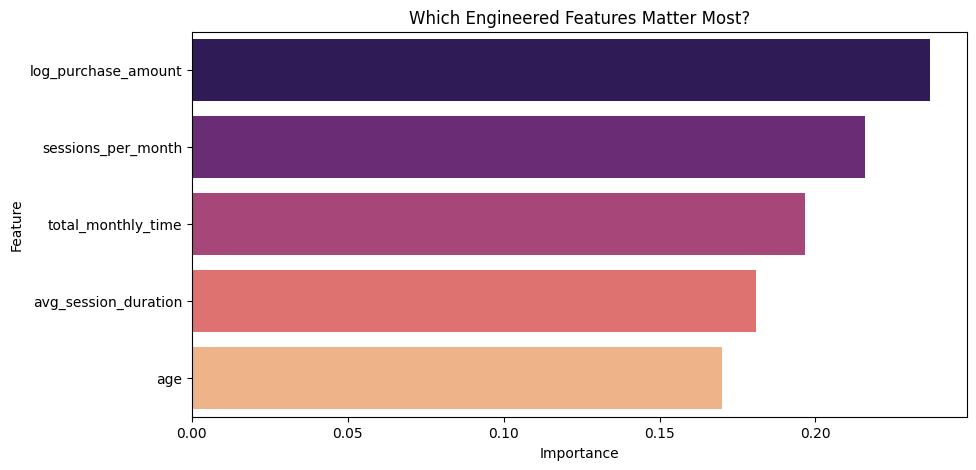

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Define our features (X) and target (y)
# We'll use the original columns plus our new interactions
features_to_check = ['age', 'sessions_per_month', 'avg_session_duration', 'total_monthly_time', 'log_purchase_amount']
X_check = df_interview[features_to_check]
y_check = df_interview['total_purchase_amount']

# 2. Fit the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_check, y_check)

# 3. Get Importance
importances = pd.DataFrame({
    'Feature': features_to_check,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x='Importance', y='Feature', palette='magma')
plt.title('Which Engineered Features Matter Most?')
plt.show()

### **Step 6: Dimensionality Reduction with PCA**
We'll now use PCA to reduce our engineered features into 2 main components. This helps us see if the variation in user behavior can be summarized by just a couple of underlying patterns.

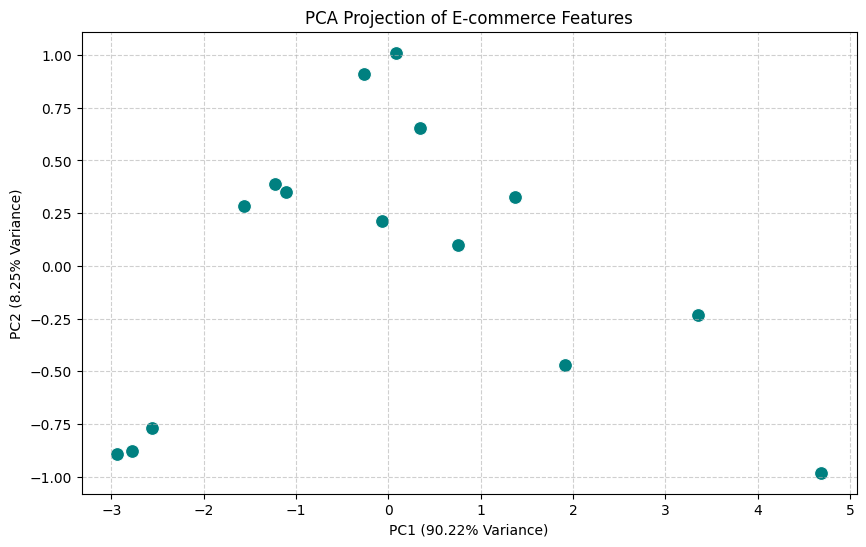

Total Variance Explained by 2 Components: 98.47%


In [ ]:
from sklearn.decomposition import PCA

# 1. We use the scaled data we created in Step 4
# (PCA must always be performed on scaled data)
pca_interview = PCA(n_components=2)
principal_components = pca_interview.fit_transform(scaled_data)

# 2. Create a DataFrame for the components
pca_interview_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)

# 3. Visualize the PCA projection
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_interview_df, x='PC1', y='PC2', s=100, color='teal')
plt.title('PCA Projection of E-commerce Features')
plt.xlabel(f'PC1 ({pca_interview.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'PC2 ({pca_interview.explained_variance_ratio_[1]:.2%} Variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Total Variance Explained by 2 Components: {pca_interview.explained_variance_ratio_.sum():.2%}")

-------
<br>




## **PRATICE SET 2**

In [1]:
import pandas as pd
import numpy as np

# Creating a synthetic 'Loan Approval' Dataset for Practice Set 2
np.random.seed(7)
n_rows = 20

data_loans = {
    'loan_id': range(500, 500 + n_rows),
    'annual_income': [45000, 60000, 120000, 30000, np.nan, 85000, 200000, 52000, 48000, np.nan, 65000, 72000, 95000, 38000, 110000, 55000, np.nan, 80000, 62000, 41000],
    'credit_score': [650, 720, 800, 580, 610, 750, 820, 690, 640, 700, 710, 730, 770, 600, 790, 680, 620, 740, 705, 660],
    'loan_amount': [15000, 20000, 50000, 5000, 12000, 35000, 100000, 18000, 14000, 22000, 25000, 28000, 40000, 9000, 45000, 17000, 15000, 32000, 21000, 13000],
    'employment_years': [2, 5, 10, 1, 3, 7, 15, 4, 2, 6, 5, 8, 9, 2, 12, 4, 3, 6, 5, 2],
    'has_co_signer': [0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1],
    'loan_purpose': ['Car', 'Home', 'Business', 'Education', 'Car', 'Home', 'Business', 'Home', 'Education', 'Car', 'Home', 'Business', 'Home', 'Car', 'Business', 'Education', 'Home', 'Home', 'Business', 'Car']
}

df_loans = pd.DataFrame(data_loans)

print("Practice Set 2: Loan Dataset")
display(df_loans.head())

print("\nMissing Values Summary:")
print(df_loans.isnull().sum())

# TASK SUGGESTIONS:
# 1. Fill missing 'annual_income' using the median.
# 2. Create a 'Debt-to-Income' ratio: (loan_amount / annual_income).
# 3. Apply Log Transform to 'loan_amount' to normalize it.
# 4. Create an interaction between 'credit_score' and 'employment_years'."

Practice Set 2: Loan Dataset


,loan_id,annual_income,credit_score,loan_amount,employment_years,has_co_signer,loan_purpose
0,500,45000.0,650,15000,2,0,Car
1,501,60000.0,720,20000,5,0,Home
2,502,120000.0,800,50000,10,0,Business
3,503,30000.0,580,5000,1,1,Education
4,504,NaN,610,12000,3,1,Car



Missing Values Summary:
loan_id             0
annual_income       3
credit_score        0
loan_amount         0
employment_years    0
has_co_signer       0
loan_purpose        0
dtype: int64


In [4]:
#STEP 1 : FIX MISSING VALUES
df_loans['annual_income'] = df_loans['annual_income'].fillna(df_loans['annual_income'].median())

In [7]:
#STEP 2: GENERATE RELATIONSHIPS BETWEEN COLUMNS
df_loans['debt_to_income'] = df_loans['loan_amount'] / df_loans['annual_income']

#STEP 3: APPLY LOG1P
df_loans['log_loan_amount'] = np.log1p(df_loans['loan_amount'])

#STEP 4: CREATE INTERACTIONS
df_loans['credit_employment_interaction'] = df_loans['credit_score'] * df_loans['employment_years']

#STEP 5: OUTPUT
display(df_loans.head(5))

,loan_id,annual_income,credit_score,loan_amount,employment_years,has_co_signer,loan_purpose,debt_to_income,log_loan_amount,credit_employment_interaction
0,500,45000.0,650,15000,2,0,Car,0.333333,9.615872,1300
1,501,60000.0,720,20000,5,0,Home,0.333333,9.903538,3600
2,502,120000.0,800,50000,10,0,Business,0.416667,10.819798,8000
3,503,30000.0,580,5000,1,1,Education,0.166667,8.517393,580
4,504,62000.0,610,12000,3,1,Car,0.193548,9.392745,1830


In [18]:
#STEP 6: IMPORT STANDARD SCALER AND POLYNOMIAL FEATURES
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

sc_l = StandardScaler()
po_l = PolynomialFeatures()

sc_scaled = sc_l.fit_transform(df_loans[['annual_income',	'credit_score',	'loan_amount', 'debt_to_income',	'log_loan_amount',	'credit_employment_interaction']])
po_scaled = po_l.fit_transform(df_loans[['annual_income',	'credit_score',	'loan_amount', 'debt_to_income',	'log_loan_amount',	'credit_employment_interaction']])

#STEP 7: OUTPUT
print("----Polynomial Scaled Data:----")
print(po_scaled[:1])
print()
print("----Standard Scaling successful! Preview of scaled features:----")
print(sc_scaled[:5].round(2))



----Polynomial Scaled Data:----
[[1.00000000e+00 4.50000000e+04 6.50000000e+02 1.50000000e+04
  3.33333333e-01 9.61587214e+00 1.30000000e+03 2.02500000e+09
  2.92500000e+07 6.75000000e+08 1.50000000e+04 4.32714247e+05
  5.85000000e+07 4.22500000e+05 9.75000000e+06 2.16666667e+02
  6.25031689e+03 8.45000000e+05 2.25000000e+08 5.00000000e+03
  1.44238082e+05 1.95000000e+07 1.11111111e-01 3.20529071e+00
  4.33333333e+02 9.24649971e+01 1.25006338e+04 1.69000000e+06]]

----Standard Scaling successful! Preview of scaled features:----
[[-0.74 -0.72 -0.58 -0.08 -0.55 -0.93]
 [-0.33  0.32 -0.33 -0.08 -0.11 -0.16]
 [ 1.29  1.52  1.13  0.95  1.29  1.29]
 [-1.14 -1.76 -1.06 -2.13 -2.24 -1.16]
 [-0.28 -1.32 -0.72 -1.8  -0.89 -0.75]]


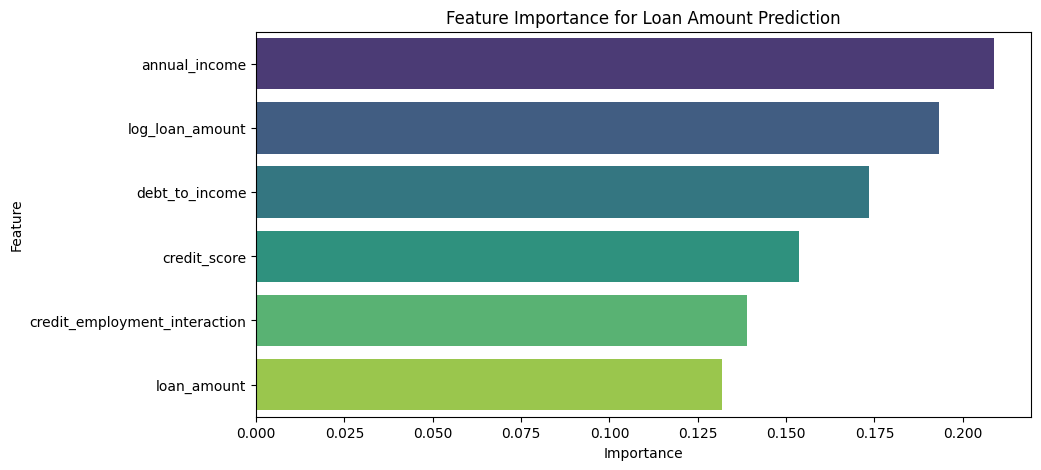

,Feature,Importance
0,annual_income,0.208908
4,log_loan_amount,0.193315
3,debt_to_income,0.173352
1,credit_score,0.153652
5,credit_employment_interaction,0.139007
2,loan_amount,0.131766


In [20]:
#STEP 8: IMPLEMENT THE MODEL
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

X_l = df_loans[['annual_income', 'credit_score', 'loan_amount', 'debt_to_income', 'log_loan_amount', 'credit_employment_interaction']]
y_l = df_loans['loan_amount']

mod_el = RandomForestRegressor(n_estimators=100, random_state=42)
mod_el.fit(X_l, y_l)

p_predict = mod_el.predict(X_l)

# FIX: Use mod_el.feature_importances_ to get the numerical scores
imp = pd.DataFrame({
    'Feature': X_l.columns,
    'Importance': mod_el.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize the results
plt.figure(figsize=(10, 5))
sns.barplot(data=imp, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance for Loan Amount Prediction')
plt.show()

display(imp)

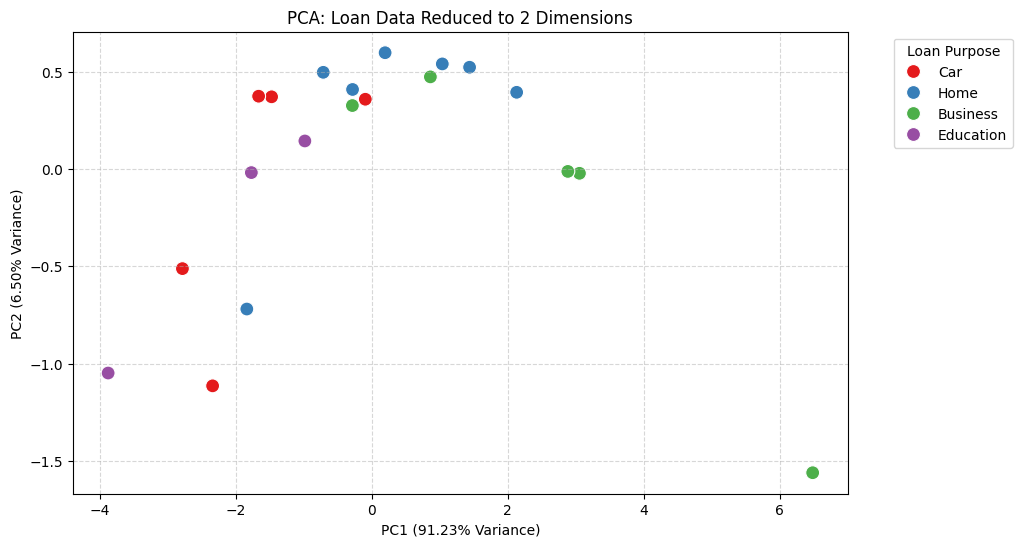

Total Variance Explained by 2 components: 97.73%


In [21]:
from sklearn.decomposition import PCA

# 1. Initialize PCA
pca_l = PCA(n_components=2)

# 2. Fit and transform using the scaled data (sc_scaled) created in Step 6
X_pca_l = pca_l.fit_transform(sc_scaled)

# 3. Create a DataFrame for visualization
df_pca_l = pd.DataFrame(data=X_pca_l, columns=['PC1', 'PC2'])
df_pca_l['loan_purpose'] = df_loans['loan_purpose'].values

# 4. Plot the results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca_l, x='PC1', y='PC2', hue='loan_purpose', s=100, palette='Set1')
plt.title('PCA: Loan Data Reduced to 2 Dimensions')
plt.xlabel(f'PC1 ({pca_l.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'PC2 ({pca_l.explained_variance_ratio_[1]:.2%} Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Loan Purpose', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print(f"Total Variance Explained by 2 components: {pca_l.explained_variance_ratio_.sum():.2%}")